In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))  # src 를 import 하기 위해

import numpy as np
import matplotlib.pyplot as plt
from src.fields.electric import PointCharge, ElectricField

print("import 성공")

import 성공


In [2]:
# +1nC 와 -1nC 를 x축 위 ±1cm 에 놓기
a = 0.01      # [m]
q = 1e-9      # [C]

field = ElectricField([
    PointCharge(+q, [-a, 0, 0]),
    PointCharge(-q, [+a, 0, 0]),
])

# xy 평면 격자 (z=0)
n = 40
x = np.linspace(-0.05, 0.05, n)
y = np.linspace(-0.05, 0.05, n)
X, Y = np.meshgrid(x, y)
R = np.stack([X, Y, np.zeros_like(X)], axis=-1)

E = field.evaluate(R)
Ex, Ey = E[..., 0], E[..., 1]

print("계산 완료. E 배열 shape:", E.shape)

계산 완료. E 배열 shape: (40, 40, 3)


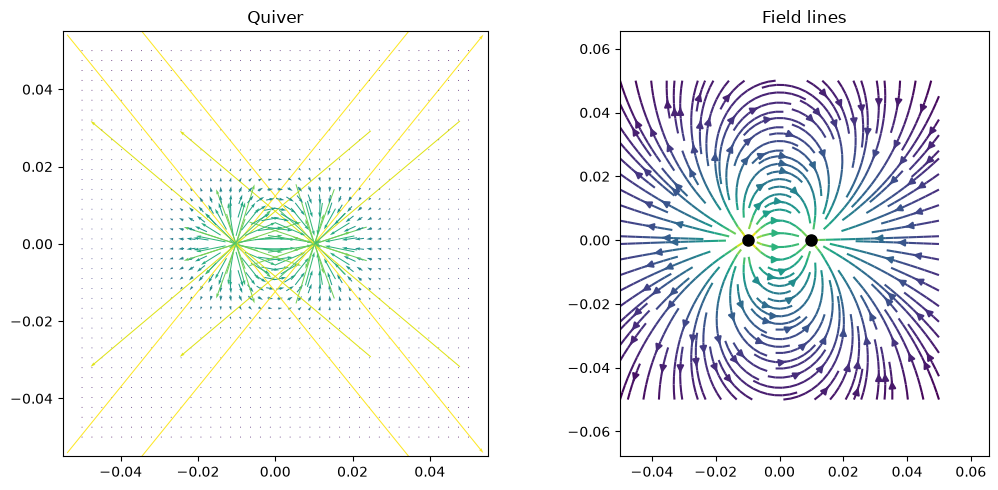

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# (a) 벡터 화살표
axes[0].quiver(X, Y, Ex, Ey, np.log(np.hypot(Ex, Ey)+1e-20), pivot="mid")
axes[0].set_title("Quiver")
axes[0].set_aspect("equal")

# (b) 전기력선
axes[1].streamplot(X, Y, Ex, Ey, density=1.4,
                   color=np.log(np.hypot(Ex, Ey)+1e-20))
axes[1].plot([-a, +a], [0, 0], "ko", ms=8)
axes[1].set_title("Field lines")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

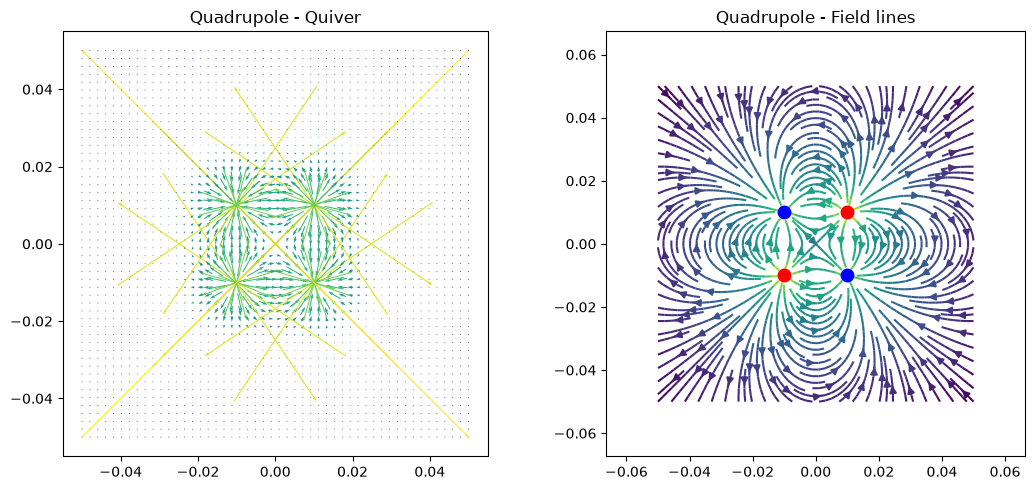

In [4]:
# 4극자: +q, -q, +q, -q 를 정사각형 꼭짓점에 배치
a = 0.01
q = 1e-9

quad = ElectricField([
    PointCharge(+q, [-a, -a, 0]),
    PointCharge(-q, [+a, -a, 0]),
    PointCharge(+q, [+a, +a, 0]),
    PointCharge(-q, [-a, +a, 0]),
])

# 격자
n = 50
xs = np.linspace(-0.05, 0.05, n)
ys = np.linspace(-0.05, 0.05, n)
Xq, Yq = np.meshgrid(xs, ys)
Rq = np.stack([Xq, Yq, np.zeros_like(Xq)], axis=-1)

Eq = quad.evaluate(Rq)
Exq, Eyq = Eq[..., 0], Eq[..., 1]

# 그리기
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

logmag = np.log(np.hypot(Exq, Eyq) + 1e-20)

axes[0].quiver(Xq, Yq, Exq, Eyq, logmag, pivot="mid")
axes[0].set_title("Quadrupole - Quiver")
axes[0].set_aspect("equal")

axes[1].streamplot(Xq, Yq, Exq, Eyq, density=1.6, color=logmag)
# 전하 위치 표시: +는 빨강, -는 파랑
for c in quad.charges:
    color = "red" if c.q > 0 else "blue"
    axes[1].plot(c.position[0], c.position[1], "o", color=color, ms=9)
axes[1].set_title("Quadrupole - Field lines")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

In [5]:
# 4극자는 원점에서 E = 0 이어야 함 (대칭성)
E_origin = quad.evaluate(np.array([0.0, 0.0, 0.0]))
print("원점에서의 E:", E_origin)
print("크기:", np.linalg.norm(E_origin), "V/m")

# 원점 근처에서 E는 매우 작아야 함
E_near = quad.evaluate(np.array([1e-5, 1e-5, 0.0]))
print("원점 근처 E:", E_near)

원점에서의 E: [0. 0. 0.]
크기: 0.0 V/m
원점 근처 E: [-190.65492333 -190.65492333    0.        ]


In [6]:
import plotly.graph_objects as go

# 다이폴 재사용 (셀 2에서 만든 field 그대로)
# 만약 커널을 재시작했다면 아래 두 줄로 다시 만들기:
a = 0.01
q = 1e-9
field3d = ElectricField([
    PointCharge(+q, [-a, 0, 0]),
    PointCharge(-q, [+a, 0, 0]),
])

# 3D 격자 (크기 주의: n=15면 15³ = 3375점, 이 이상은 무거움)
n3 = 12
L = 0.04
xs = np.linspace(-L, L, n3)
ys = np.linspace(-L, L, n3)
zs = np.linspace(-L, L, n3)
X3, Y3, Z3 = np.meshgrid(xs, ys, zs, indexing="ij")
R3 = np.stack([X3, Y3, Z3], axis=-1)     # (n, n, n, 3)

E3 = field3d.evaluate(R3)                # (n, n, n, 3)
Ex3, Ey3, Ez3 = E3[..., 0], E3[..., 1], E3[..., 2]

# 벡터 크기가 너무 큰 곳(전하 근처)은 화살표가 화면을 뒤덮으니 클리핑
mag = np.sqrt(Ex3**2 + Ey3**2 + Ez3**2)
cap = np.percentile(mag, 90)   # 상위 10%는 잘라내기
scale = np.minimum(mag, cap) / (mag + 1e-30)
Ex3, Ey3, Ez3 = Ex3*scale, Ey3*scale, Ez3*scale

fig3d = go.Figure(data=[
    # 벡터장 (원뿔로 표시)
    go.Cone(
        x=X3.flatten(), y=Y3.flatten(), z=Z3.flatten(),
        u=Ex3.flatten(), v=Ey3.flatten(), w=Ez3.flatten(),
        sizemode="absolute", sizeref=0.004,
        colorscale="Viridis",
        showscale=True,
        colorbar=dict(title="|E| (clipped)"),
    ),
    # +q (빨강)
    go.Scatter3d(
        x=[-a], y=[0], z=[0], mode="markers",
        marker=dict(size=8, color="red"),
        name="+q",
    ),
    # -q (파랑)
    go.Scatter3d(
        x=[+a], y=[0], z=[0], mode="markers",
        marker=dict(size=8, color="blue"),
        name="-q",
    ),
])

fig3d.update_layout(
    title="Dipole electric field (3D)",
    scene=dict(
        xaxis_title="x [m]",
        yaxis_title="y [m]",
        zaxis_title="z [m]",
        aspectmode="cube",
    ),
    width=750, height=650,
)

fig3d.show()

In [7]:
# 시작점: xy 평면 위 링 형태로 12개
theta = np.linspace(0, 2*np.pi, 12, endpoint=False)
r_start = 0.005
sx = r_start * np.cos(theta)
sy = r_start * np.sin(theta)
sz = np.zeros_like(sx)

# 전기장을 시각화용으로 재계산 (클리핑 안 함, 원본)
E3_raw = field3d.evaluate(R3)

fig_tube = go.Figure(data=[
    go.Streamtube(
        x=X3.flatten(), y=Y3.flatten(), z=Z3.flatten(),
        u=E3_raw[...,0].flatten(),
        v=E3_raw[...,1].flatten(),
        w=E3_raw[...,2].flatten(),
        starts=dict(x=sx.tolist(), y=sy.tolist(), z=sz.tolist()),
        sizeref=0.3,
        colorscale="Plasma",
        maxdisplayed=3000,
    ),
    go.Scatter3d(x=[-a], y=[0], z=[0], mode="markers",
                 marker=dict(size=8, color="red"), name="+q"),
    go.Scatter3d(x=[+a], y=[0], z=[0], mode="markers",
                 marker=dict(size=8, color="blue"), name="-q"),
])

fig_tube.update_layout(
    title="Dipole field lines (3D streamtubes)",
    scene=dict(aspectmode="cube"),
    width=750, height=650,
)
fig_tube.show()

C:\Users\selfso\AppData\Local\Temp\ipykernel_17396\332305622.py:37: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\selfso\AppData\Local\Temp\ipykernel_17396\332305622.py:37: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\selfso\AppData\Local\Temp\ipykernel_17396\332305622.py:37: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\selfso\AppData\Local\Temp\ipykernel_17396\332305622.py:37: UserWarning: Glyph 48512 (\N{HANGUL SYLLABLE BU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\selfso\AppData\Local\Temp\ipykernel_17396\332305622.py:37: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\selfso\AppData\Local\Temp\ipykernel_17396\332305622.py:37: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from 

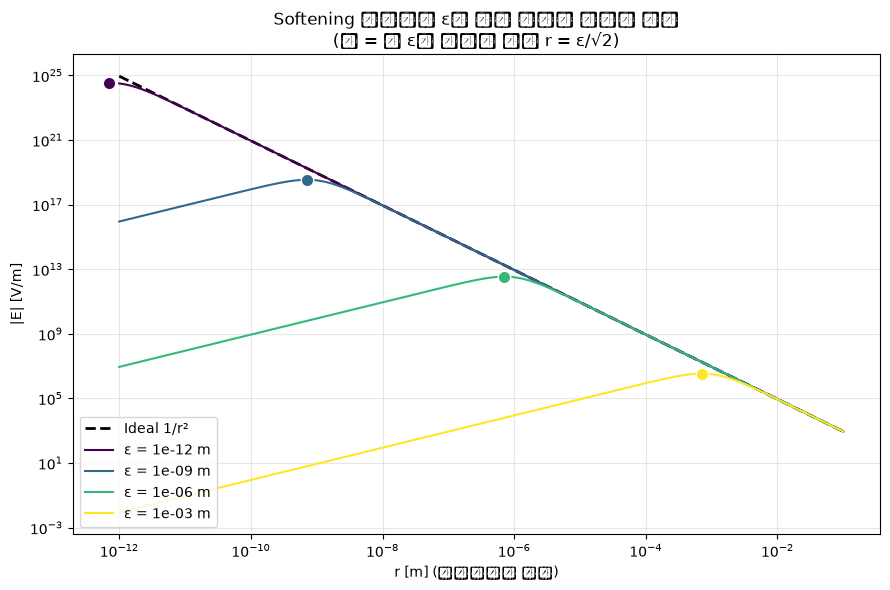

In [8]:
from src.utils.constants import K_E

def E_mag_softened(r, q, eps):
    """단일 점전하가 원점에 있을 때 거리 r 지점의 |E|. softening ε 포함."""
    return K_E * abs(q) * r / (r**2 + eps**2)**1.5

# 거리 스캔 (1 pm ~ 10 cm, log 스케일 500점)
r_arr = np.logspace(-12, -1, 500)
q_test = 1e-9

# 시험할 ε 값들 (12자릿수 범위)
epsilons = [1e-12, 1e-9, 1e-6, 1e-3]
colors = ["#440154", "#31688e", "#35b779", "#fde725"]

fig, ax = plt.subplots(figsize=(9, 6))

# 이상적 쿨롱 (ε=0)
E_ideal = K_E * q_test / r_arr**2
ax.loglog(r_arr, E_ideal, "k--", label="Ideal 1/r²", linewidth=2)

# 각 ε에 대해
for eps, color in zip(epsilons, colors):
    E_soft = E_mag_softened(r_arr, q_test, eps)
    ax.loglog(r_arr, E_soft, color=color,
              label=f"ε = {eps:.0e} m", linewidth=1.5)
    # 각 곡선의 최대값 위치 (수식적으로 r = ε/√2 에서)
    r_peak = eps / np.sqrt(2)
    E_peak = E_mag_softened(np.array([r_peak]), q_test, eps)[0]
    ax.plot([r_peak], [E_peak], "o", color=color, ms=9,
            markeredgecolor="white", markeredgewidth=1)

ax.set_xlabel("r [m] (전하로부터 거리)")
ax.set_ylabel("|E| [V/m]")
ax.set_title("Softening 파라미터 ε가 근접 필드에 미치는 영향\n(점 = 각 ε의 최댓값 위치 r = ε/√2)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [9]:
# 어떤 거리에서 몇 %의 오차가 나는가?
print(f"{'r [m]':>10} | " + " | ".join([f'ε={e:.0e}: err%' for e in epsilons]))
print("-" * 85)

test_r = [1e-9, 1e-8, 1e-6, 1e-4, 1e-3, 1e-2]
for r in test_r:
    E_true = K_E * q_test / r**2
    errs = []
    for eps in epsilons:
        E_s = E_mag_softened(np.array([r]), q_test, eps)[0]
        rel_err = abs(E_s - E_true) / E_true * 100
        errs.append(f"{rel_err:12.3e}")
    print(f"{r:10.1e} | " + " | ".join(errs))

     r [m] | ε=1e-12: err% | ε=1e-09: err% | ε=1e-06: err% | ε=1e-03: err%
-------------------------------------------------------------------------------------
   1.0e-09 |    1.500e-04 |    6.464e+01 |    1.000e+02 |    1.000e+02
   1.0e-08 |    1.500e-06 |    1.481e+00 |    1.000e+02 |    1.000e+02
   1.0e-06 |    1.500e-10 |    1.500e-04 |    6.464e+01 |    1.000e+02
   1.0e-04 |    1.326e-14 |    1.500e-08 |    1.500e-02 |    9.990e+01
   1.0e-03 |    0.000e+00 |    1.500e-10 |    1.500e-04 |    6.464e+01
   1.0e-02 |    1.619e-14 |    1.506e-12 |    1.500e-06 |    1.481e+00


In [10]:
grid_spacing = 0.05 / 40   # 앞서 사용한 격자 간격 (m)
print(f"우리 격자 간격 h = {grid_spacing*1000:.3f} mm")
print()
print("경험 법칙: ε를 격자 간격 h 의 5~10% 로 잡으면 실용적.")
print(f"  → 권장 ε = {grid_spacing*0.05:.1e} ~ {grid_spacing*0.10:.1e} m")
print()
print(f"현재 코드의 SOFTENING = {1e-9:.1e} m")
print(f"  → 이것은 h의 {1e-9/grid_spacing*100:.2e}% — 매우 보수적 (원본 물리 거의 왜곡 없음)")
print(f"  → 다만 격자 점이 전하와 정확히 h 이내로 가까워지면 발산 위험 있음")

우리 격자 간격 h = 1.250 mm

경험 법칙: ε를 격자 간격 h 의 5~10% 로 잡으면 실용적.
  → 권장 ε = 6.3e-05 ~ 1.3e-04 m

현재 코드의 SOFTENING = 1.0e-09 m
  → 이것은 h의 8.00e-05% — 매우 보수적 (원본 물리 거의 왜곡 없음)
  → 다만 격자 점이 전하와 정확히 h 이내로 가까워지면 발산 위험 있음
